# Model fitting 2: Only SSC, MCMC without minimizer step and ultranest backend

In [1]:
#import warnings
#warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc3


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



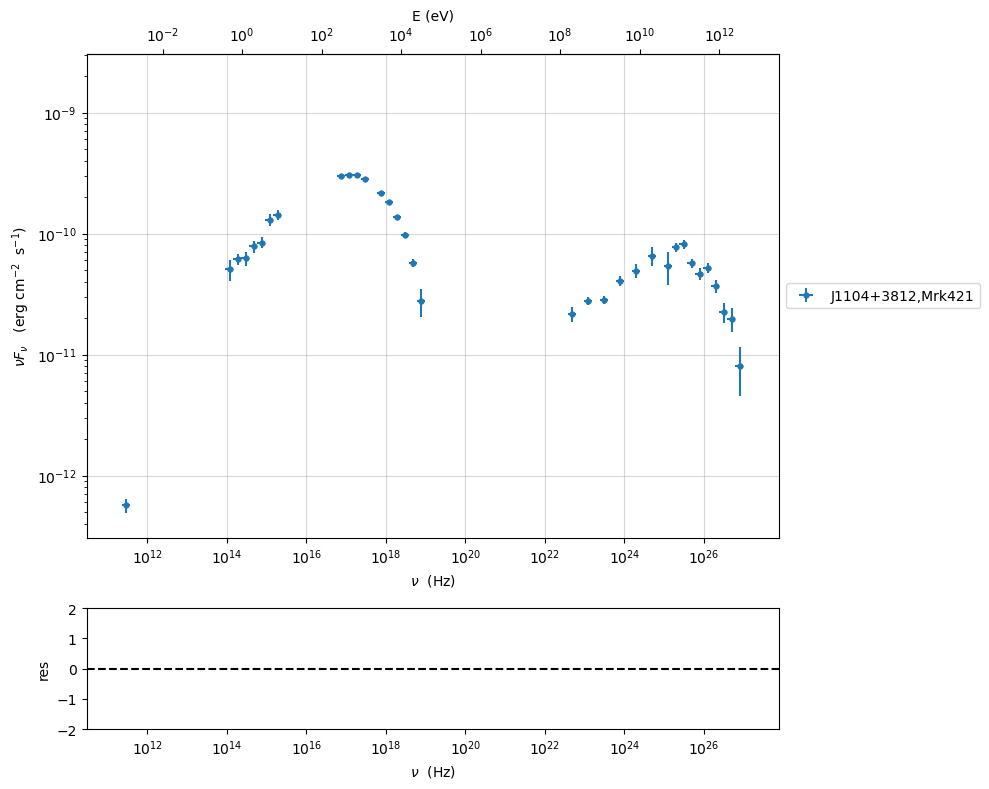

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**16])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## creating and setting the sampler

In [7]:

from jetset.mcmc_ultranest import UltraNestSampler
from jetset.minimizer import ModelMinimizer


In [8]:
from jetset.jet_model import Jet
from jetset.model_manager import FitModel
fit_model=FitModel(jet=Jet(emitters_distribution='plc'),name='plain_plc')

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using the one from jet FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


We create a `ModelMinimizer` object directly for the MCMC step, skipping the `.run()` method, replaced by the call of the `prepare_fit` method.

In [9]:
model_minimizer = model_minimizer=ModelMinimizer('mcmc')
model_minimizer.prepare_fit(fit_model,
                            sed_data,
                            nu_fit_start=1E11,
                            nu_fit_stop=1E29,
                            use_UL=True)



filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34


to speed up the utlranest sampler we make parameters logarithmic:


In [10]:
model_minimizer.fit_model.jet_leptonic.parameters.R.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.B.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.N.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmax.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmin.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gamma_cut.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.z_cosm.freeze()


In [11]:
model_minimizer.fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False


None

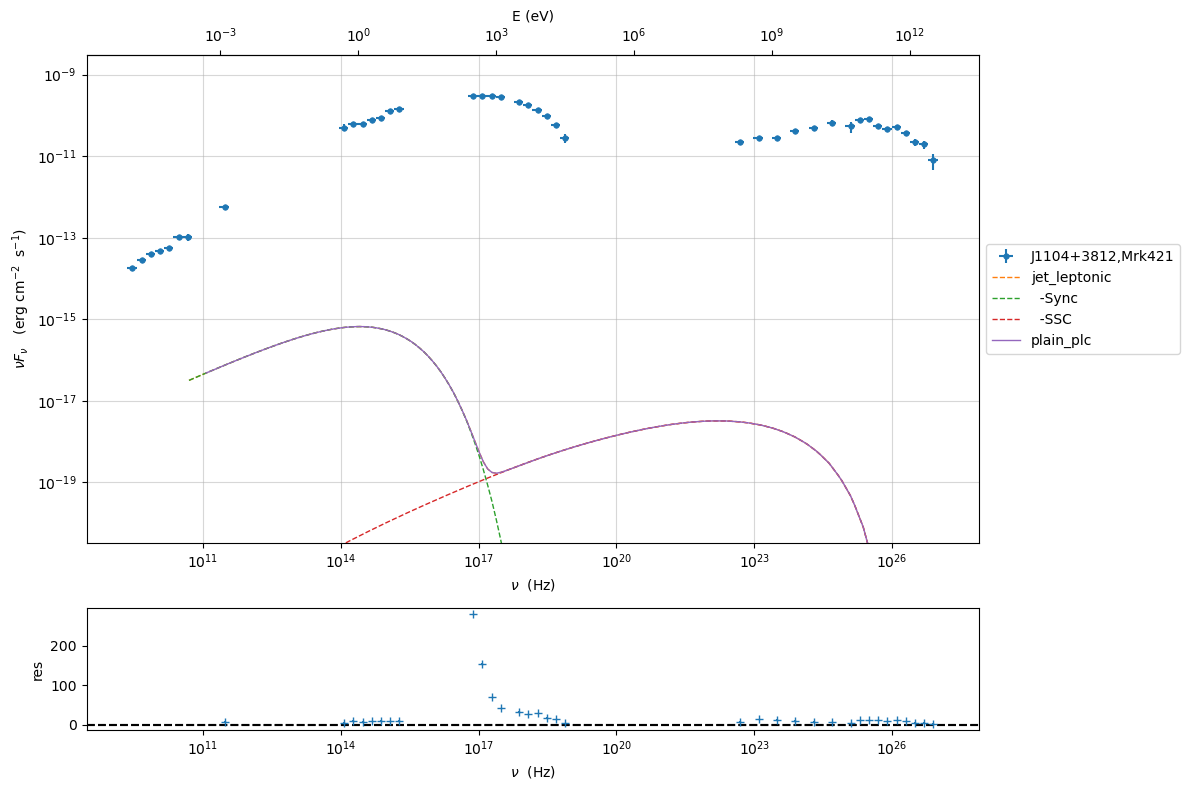

In [12]:
model_minimizer.fit_model.eval()
p=model_minimizer.fit_model.plot_model(sed_data=sed_data)

In [13]:

mcmc=UltraNestSampler(model_minimizer)

In [14]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

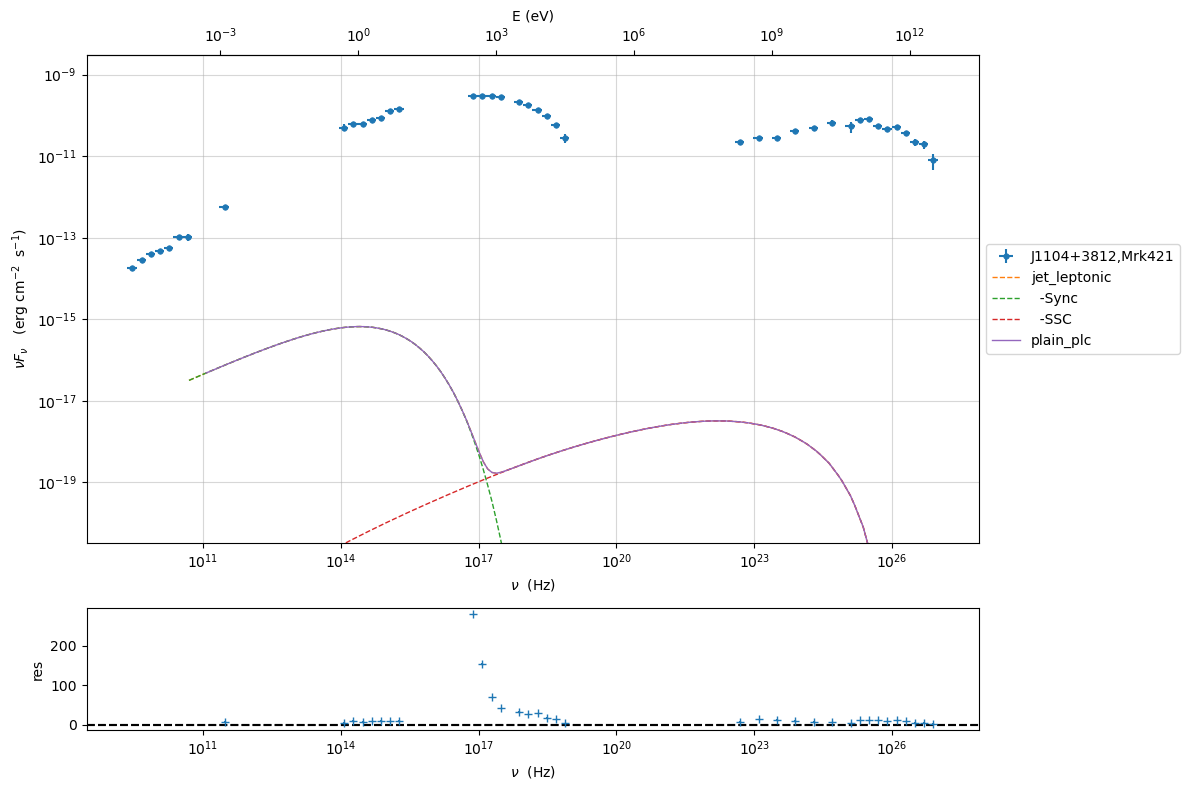

In [15]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

You can inspect the mcmc parameters using:

In [16]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,True,6.000000e+00,--,--,--,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-2.000000e+02,--,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,3.000000e+00,3.000000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-2.000000e+02,--,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e-04,--,False
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


In [17]:
mcmc.model.parameters.best_fit_par_table

model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
str12,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,--,--,--,3.010300e-01,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,--,--,--,6.000000e+00,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,--,--,--,2.000000e+00,-2.000000e+02,--,False
jet_leptonic,gamma_cut,4.000000e+00,--,--,--,4.000000e+00,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,--,--,--,2.000000e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,--,--,--,1.569897e+01,3.000000e+00,3.000000e+01,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,-1.000000e+00,--,--,--,-1.000000e+00,-2.000000e+02,--,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


If you want to exclude or include parameters from the samplers just freeze/free them 

In [18]:
mcmc.model.jet_leptonic.parameters.gmax.freeze()
mcmc.model.jet_leptonic.parameters.gmax.val=7

mcmc.set_bounds(par_name='p',comp_name='jet_leptonic',par_bounds=[1.5,3.5])
mcmc.set_bounds(par_name='N',comp_name='jet_leptonic',par_bounds=[-3,3])
mcmc.set_bounds(par_name='R',comp_name='jet_leptonic',par_bounds=[15,17])
mcmc.set_bounds(par_name='beam_obj',comp_name='jet_leptonic',par_bounds=[10,50])


mcmc.set_bounds(par_name='gmin',comp_name='jet_leptonic',par_bounds=[0,3.3])
mcmc.set_bounds(par_name='gamma_cut',comp_name='jet_leptonic',par_bounds=[3,6])
mcmc.set_bounds(par_name='B',comp_name='jet_leptonic',par_bounds=[-3,0])
 


par: p  ref value:  2.0  mcmc bounds: [1.5, 3.5]
par: N  ref value:  2.0  mcmc bounds: [np.float64(-3.0), np.float64(3.0)]
par: R  ref value:  15.698970004336019  mcmc bounds: [np.float64(15.0), np.float64(17.0)]
par: beam_obj  ref value:  10.0  mcmc bounds: [10, 50]
par: gmin  ref value:  0.3010299956639812  mcmc bounds: [np.float64(0.0), np.float64(3.3)]
par: gamma_cut  ref value:  4.0  mcmc bounds: [np.float64(3.0), np.float64(6.0)]
par: B  ref value:  -1.0  mcmc bounds: [np.float64(-3.0), np.float64(0.0)]


In [19]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,7.000000e+00,0.000000e+00,1.500000e+01,True,True
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

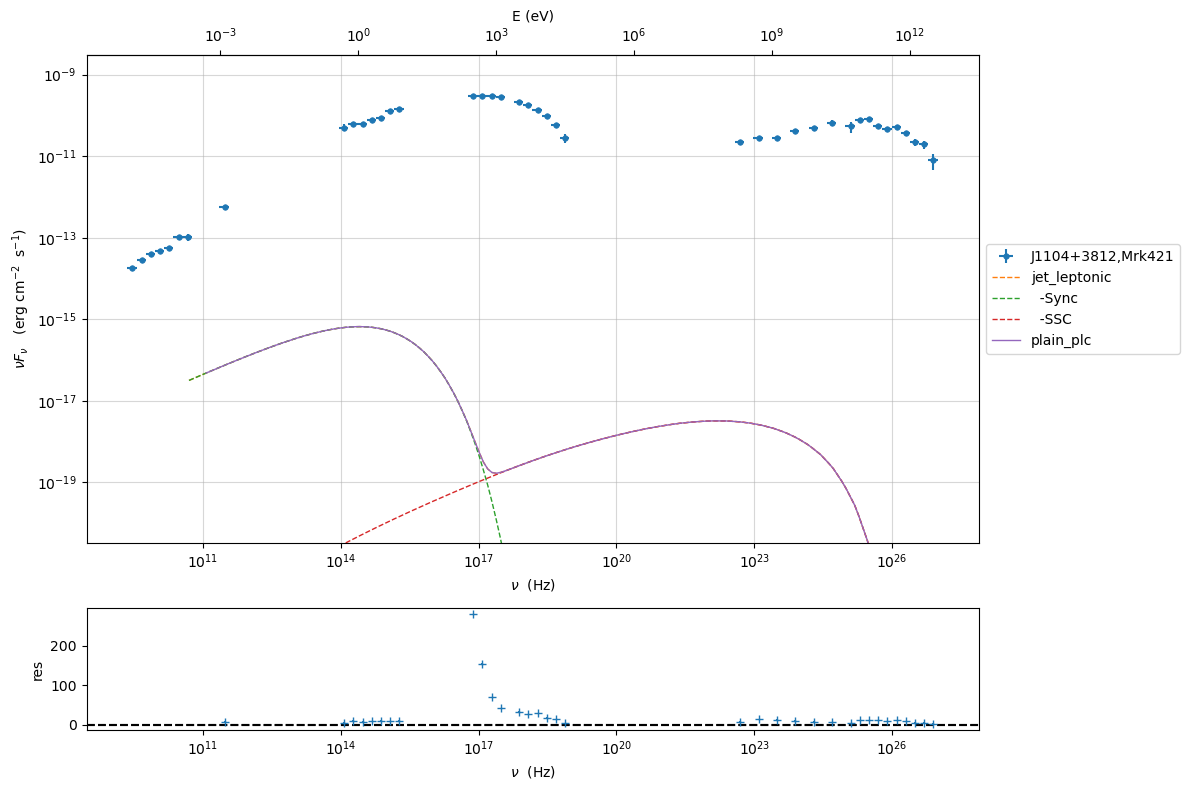

In [20]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

In [21]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,3.300000e+00,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


## Running the sampler using Open MPI 

When using `run_open_mpi`, the root directory, storing the ultranest products and the mpi script will be `run_mpi`

The parameter `ultranest_output_dir`, created under `run_mpi`, by default, will be set to `f'ultranest_{self.model.name}'`. You can override it by passing the desired name.


Setting `n_proc=8`, will result in running 8 parallel processes, speeding up the sampler, increase the `n_proc` value up to the number of cores/cpus depending on your machine/cluster setup


In [22]:
from jetset.mcmc_ultranest import run_open_mpi

mcmc=run_open_mpi(mcmc,
                 n_proc=8, #it runs 8 parallel processes, speeding up the sampler, increase n_proc value up to the number of cores/cpus depending on yor machine/cluster setup
                 min_num_live_points=64,
                 nsteps=1,
                 max_num_improvement_loops=1, 
                 min_ess=100,
                 num_c_threads=0, #when using openmpi do not enable c-threads
                 ultranest_output_dir='ultranest_openmpi_runs', #to override the directory storing the ultranest products to be inspected if needed , placed in run_mpi/
)

====== ultranest script ========
from jetset.mcmc_ultranest import UltraNestSampler
mcmc=UltraNestSampler.load('sampler.pkl')

mcmc.model.set_num_c_threads(0)

mcmc.run_sampler(
                min_num_live_points=64,
                nsteps=1,
                max_num_improvement_loops=1,
                min_ess=100.0,
                ultranest_output_dir='ultranest_openmpi_runs',
            )
    
mcmc.save('sampler.pkl')

executing mpirun  -np 8 python run_jetset_ultranest.py


Creating directory for new run ultranest_openmpi_runs/run1
ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

[ultranest] Sampling 64 live points from prior ...


Mono-modal Volume: ~exp(-0.96) * Expected Volume: exp(0.00) Quality: ok

gmin     :      +0.0| ******  ********* **    * *** * * ***** **** **|     +3.3
N        :      -3.0|*** ** ******** ** ** ***  *** *   *****  **  **|     +3.0
gamma_cut:      +3.0|**** *** ** *** ***** * * ****** *** *** **** **|     +6.0
p        :      +1.5|***** **** * * *** **  ***** *** ****** ******* |     +3.5
R        :     +15.0|* ** * ** ****  *  ********* **** ****  **  ****|    +17.0
B        :  -3.0e+00|********** ******** ****** *   **** ** **** ****| -3.0e-06
beam_obj :     +10.0|****** *  ******  * * ***  ***  ***** *  ***** *|    +50.0



Z=-56944.0(0.00%) | Like=-56940.77..-2421.06 [-4.618e+08..-5.694e+04] | it/evals=12/200 eff=8.8235% N=64 

Mono-modal Volume: ~exp(-1.28) * Expected Volume: exp(-0.23) Quality: ok
Step sampler performance: 0.7 rej/step, 7 steps/it, rel jump distance: 0.53 (should be >1), 0.00% (should be >50%)

gmin     :      +0.0| ****** *** *****  **   ** *** * * ***** **** **|     +3.3
N        :      -3.0|****** ************** ***  ******  ***** **** **|     +3.0
gamma_cut:      +3.0|**** *** ****** ***** * ** ********  **  **** **|     +6.0
p        :      +1.5| ****  *** ******* **  ***** ***  ***** ******* |     +3.5
R        :     +15.0|* ** *  * ****   ***********  **  ***** **  ****|    +17.0
B        :  -3.0e+00|* ******** *******  ****** *   ******* **** ****| -3.0e-06
beam_obj :     +10.0|****** *  ******* * * ***  ***  *  ****  ***** *|    +50.0

Z=-56942.5(0.00%) | Like=-56940.77..-2421.06 [-4.618e+08..-5.694e+04] | it/evals=24/352 eff=8.3333% N=64 

Mono-modal Volume: ~exp(-1.53) * Exp

Z=-56941.8(0.00%) | Like=-56940.76..-2421.06 [-56940.7564..-56939.5226] | it/evals=42/568 eff=8.3333% N=64 

Mono-modal Volume: ~exp(-1.53)   Expected Volume: exp(-0.70) Quality: ok
Step sampler performance: 0.7 rej/step, 7 steps/it, rel jump distance: 0.79 (should be >1), 25.00% (should be >50%)

gmin     :      +0.0| ****    * **   *  **   **  ** *** ********** * |     +3.3
N        :      -3.0|*  *** ***** * ***** ** * * **** ******* * ** **|     +3.0
gamma_cut:      +3.0|** * * ****  **  * ** **** ** ********* **** * *|     +6.0
p        :      +1.5| ***** ***  *** ** ** ****** **  * **** *** ****|     +3.5
R        :     +15.0|*  * *  ******  ******** **** *** ** *  *** *** |    +17.0
B        :  -3.0e+00|* * *  *********** *** ***** * ************ ****| -3.0e-06
beam_obj :     +10.0|* * **** **** *** * * **** ******* ** *  ****  *|    +50.0

[ultranest] Found 1 clusters, but only have 64 live points, want 80.
[ultranest] Explored until L=-6e+04  
[ultranest] Likelihood function e

Z=-56941.5(0.00%) | Like=-56940.63..-2421.06 [-56940.7589..-56939.3198] | it/evals=72/984 eff=7.3370% N=80 

Mono-modal Volume: ~exp(-2.09) * Expected Volume: exp(-0.94) Quality: ok
Step sampler performance: 1.1 rej/step, 7 steps/it, rel jump distance: 0.82 (should be >1), 16.67% (should be >50%)

gmin     :  +3.3e-06|**** *  ** **** **** *  **  *****  *************| +3.3e+00
N        :      -3.0|**  ** *******  ** * ** * ******************* **|     +3.0
gamma_cut:      +3.0|*****   **** *   * ** **** ** **************** *|     +6.0
p        :      +1.5| ***** **** ********* *********  * **** * ******|     +3.5
R        :     +15.0|* ** *  * ******* ****** *******  **** **** ****|    +17.0
B        :  -3.0e+00|* **  ** ******** **** ******************* *****| -3.0e-06
beam_obj :     +10.0|*** ** * ******** *** **** ******  ****  * ** **|    +50.0

Z=-56941.3(0.00%) | Like=-56939.93..-2421.06 [-56940.7589..-56939.3198] | it/evals=90/1232 eff=7.3052% N=80 

Mono-modal Volume: ~exp(-2.28)

...

Z=-46.2(98.74%) | Like=-17.45..-17.19 [-17.5703..-17.4341] | it/evals=2262/75120 eff=2.9542% N=64 

Mono-modal Volume: ~exp(-34.04)   Expected Volume: exp(-33.20) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.38 (should be >1), 9.29% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.95
   positive degeneracy between gamma_cut and gmin: rho=0.95
   negative degeneracy between gamma_cut and N: rho=-0.97
   positive degeneracy between R and gmin: rho=0.89
   negative degeneracy between R and N: rho=-0.97
   positive degeneracy between R and gamma_cut: rho=0.95
   negative degeneracy between B and gmin: rho=-0.90
   positive degeneracy between B and N: rho=0.87
   negative degeneracy between B and gamma_cut: rho=-0.93
   negative degeneracy between B and R: rho=-0.81
   positive degeneracy between beam_obj and N: rho=0.79
   negative degeneracy between beam_obj and R: rho=-0.86
gmin     :      +0.0|                                +2.

Z=-46.2(98.99%) | Like=-17.41..-17.18 [-17.4327..-17.3453] | it/evals=2278/75800 eff=2.9488% N=64 

Mono-modal Volume: ~exp(-34.04)   Expected Volume: exp(-33.43) Quality: ok
Step sampler performance: 1.5 rej/step, 7 steps/it, rel jump distance: 0.39 (should be >1), 9.25% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.94
   positive degeneracy between gamma_cut and gmin: rho=0.95
   negative degeneracy between gamma_cut and N: rho=-0.97
   positive degeneracy between R and gmin: rho=0.88
   negative degeneracy between R and N: rho=-0.98
   positive degeneracy between R and gamma_cut: rho=0.95
   negative degeneracy between B and gmin: rho=-0.89
   positive degeneracy between B and N: rho=0.86
   negative degeneracy between B and gamma_cut: rho=-0.92
   negative degeneracy between B and R: rho=-0.79
   negative degeneracy between beam_obj and R: rho=-0.81
gmin     :      +0.0|                                +2.7  ***       |     +3.3
N        :      -1.0|           

Z=-46.2(99.17%) | Like=-17.37..-17.18 [-17.4327..-17.3453] | it/evals=2292/76544 eff=2.9383% N=64 

Mono-modal Volume: ~exp(-34.04)   Expected Volume: exp(-33.67) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.38 (should be >1), 9.19% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.94
   positive degeneracy between gamma_cut and gmin: rho=0.95
   negative degeneracy between gamma_cut and N: rho=-0.98
   positive degeneracy between p and gmin: rho=0.78
   positive degeneracy between R and gmin: rho=0.88
   negative degeneracy between R and N: rho=-0.98
   positive degeneracy between R and gamma_cut: rho=0.95
   negative degeneracy between B and gmin: rho=-0.89
   positive degeneracy between B and N: rho=0.86
   negative degeneracy between B and gamma_cut: rho=-0.93
   negative degeneracy between B and R: rho=-0.81
   negative degeneracy between beam_obj and R: rho=-0.79
gmin     :      +0.0|                                +2.7  *

Z=-46.2(99.34%) | Like=-17.35..-17.16 [-17.4327..-17.3453] | it/evals=2308/77216 eff=2.9334% N=64 

Mono-modal Volume: ~exp(-34.04)   Expected Volume: exp(-33.90) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.38 (should be >1), 9.15% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.93
   positive degeneracy between gamma_cut and gmin: rho=0.94
   negative degeneracy between gamma_cut and N: rho=-0.96
   positive degeneracy between R and gmin: rho=0.86
   negative degeneracy between R and N: rho=-0.98
   positive degeneracy between R and gamma_cut: rho=0.93
   negative degeneracy between B and gmin: rho=-0.81
   positive degeneracy between B and N: rho=0.76
   negative degeneracy between B and gamma_cut: rho=-0.87
   positive degeneracy between beam_obj and N: rho=0.78
   negative degeneracy between beam_obj and R: rho=-0.85
gmin     :      +0.0|                                +2.7  ***       |     +3.3
N        :      -1.0|     

[ultranest] Writing samples and results to disk ... done
[ultranest] Reached maximum number of improvement loops.
[ultranest] done iterating.
ultranest run done, took 48.96 seconds
----------------------------
UltraNest best fit solution
comp: jet_leptonic par: gmin ultranest best fit val: 2.7039399331117946 quantiles(0.16,0.5,0.84): [2.66792809 2.72864488 2.7952166 ]
comp: jet_leptonic par: N ultranest best fit val: 0.06947923901070752 quantiles(0.16,0.5,0.84): [-0.22336781 -0.0635162   0.1303388 ]
comp: jet_leptonic par: gamma_cut ultranest best fit val: 5.174294825116434 quantiles(0.16,0.5,0.84): [5.15457591 5.20786619 5.25133867]
comp: jet_leptonic par: p ultranest best fit val: 2.1917367954120937 quantiles(0.16,0.5,0.84): [2.17329961 2.19345795 2.21310039]
comp: jet_leptonic par: R ultranest best fit val: 16.361770740180685 quantiles(0.16,0.5,0.84): [16.33295421 16.44525724 16.54024954]
comp: jet_leptonic par: B ultranest best fit val: -1.1252469003025782 quantiles(0.16,0.5,0.84):

[<Figure size 1000x2100 with 7 Axes>]

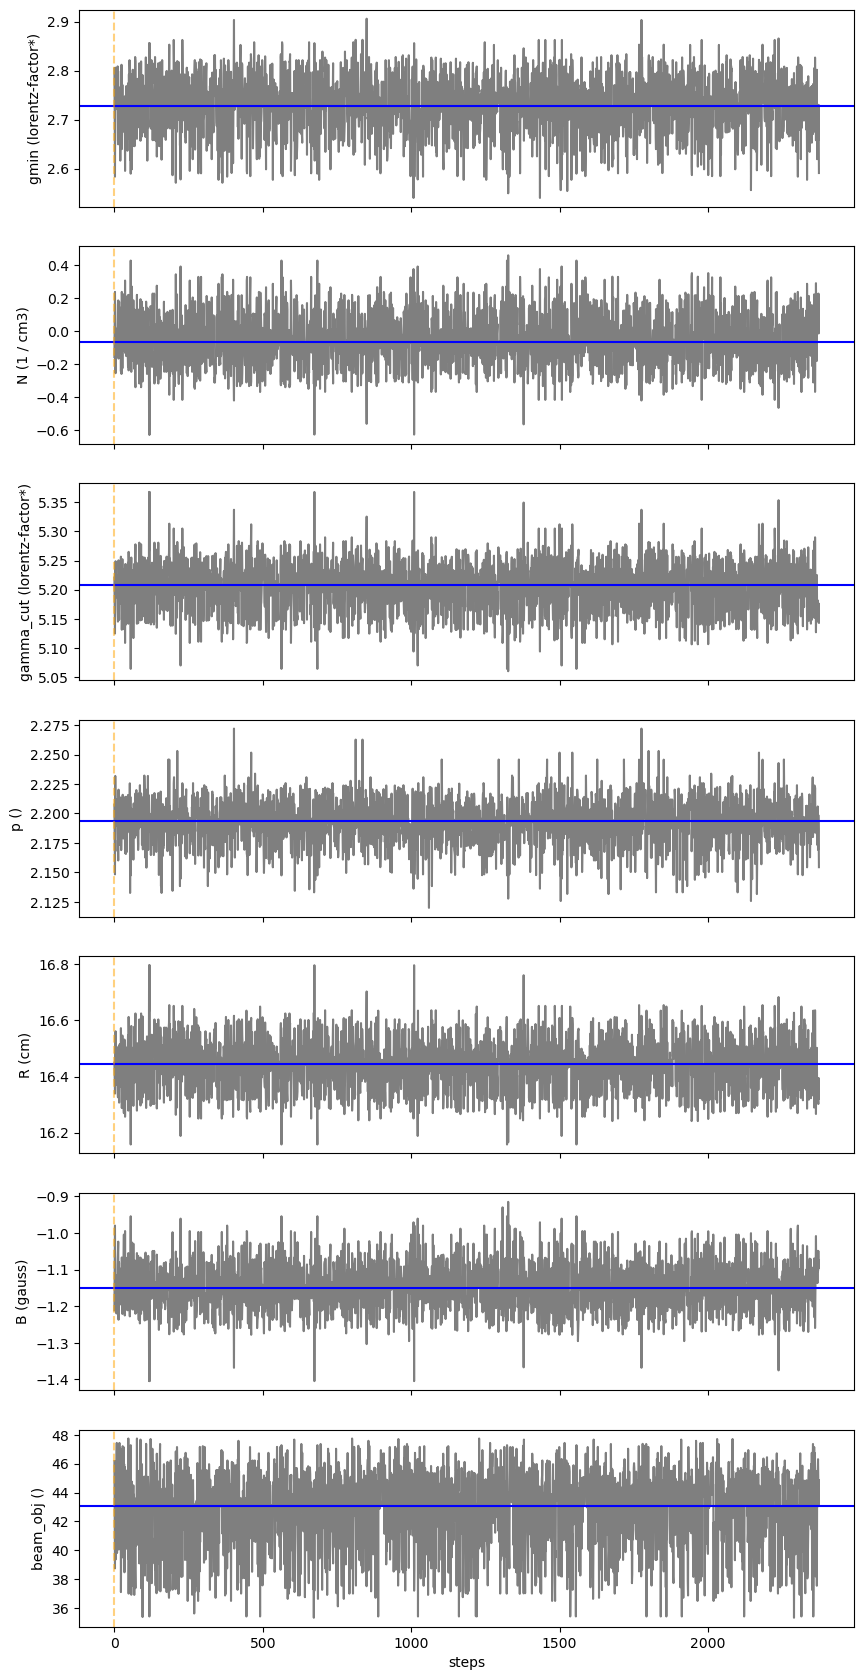

In [23]:
mcmc.plot_chain()

In [24]:
#mcmc.tune_burnin(tau_cor_coeff=4)

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [25]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.703940e+00,True,2.703940e+00,2.667928e+00,2.728645e+00,2.795217e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,6.947924e-02,True,6.947924e-02,-2.233678e-01,-6.351620e-02,1.303388e-01,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.174295e+00,True,5.174295e+00,5.154576e+00,5.207866e+00,5.251339e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.191737e+00,False,2.191737e+00,2.173300e+00,2.193458e+00,2.213100e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.636177e+01,True,1.636177e+01,1.633295e+01,1.644526e+01,1.654025e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.125247e+00,True,-1.125247e+00,-1.214193e+00,-1.150204e+00,-1.078924e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,4.600912e+01,False,4.600912e+01,3.951106e+01,4.309077e+01,4.548385e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [26]:
mcmc.set_plot_label('N',r'log($N$)',comp_name='jet_leptonic')
mcmc.set_plot_label('R',r'log($R$)',comp_name='jet_leptonic')
mcmc.set_plot_label('B',r'log($B$)',comp_name='jet_leptonic')

mcmc.set_plot_label('gmin',r'log($\gamma_{\rm min}$)',comp_name='jet_leptonic')
mcmc.set_plot_label('p',r'$p$',comp_name='jet_leptonic')
#mcmc.set_plot_label('r',r'$r$',comp_name='jet_leptonic')
mcmc.set_plot_label('gamma_cut',r'$\gamma_{\rm cut}$',comp_name='jet_leptonic')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='jet_leptonic')



the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

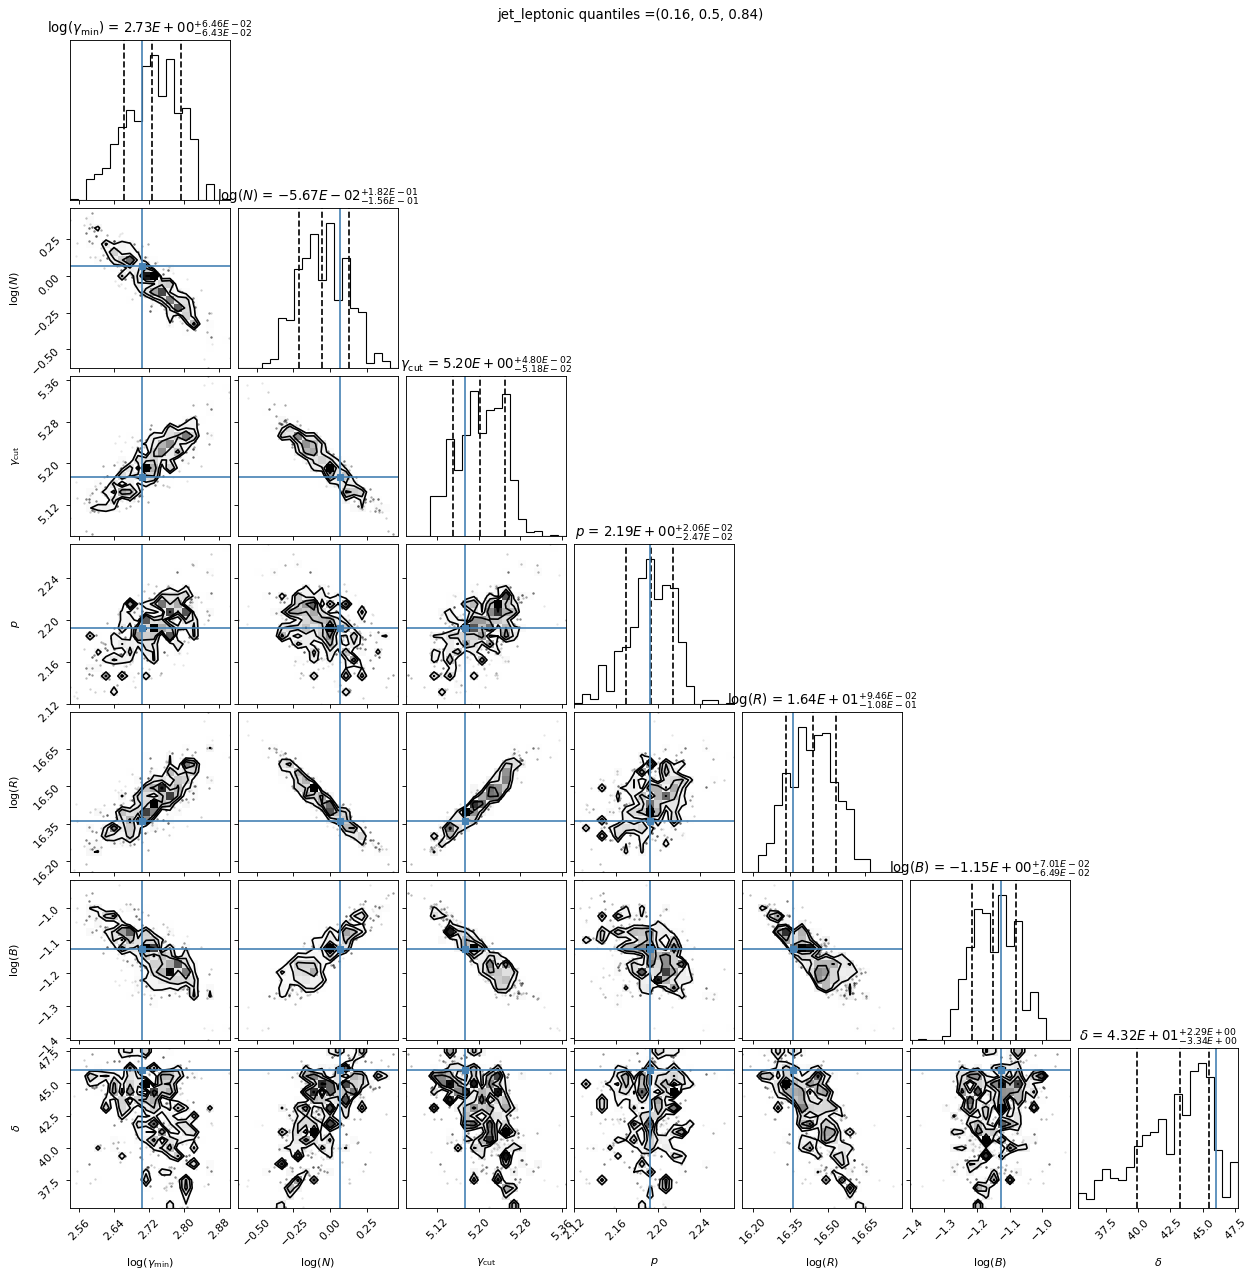

In [27]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


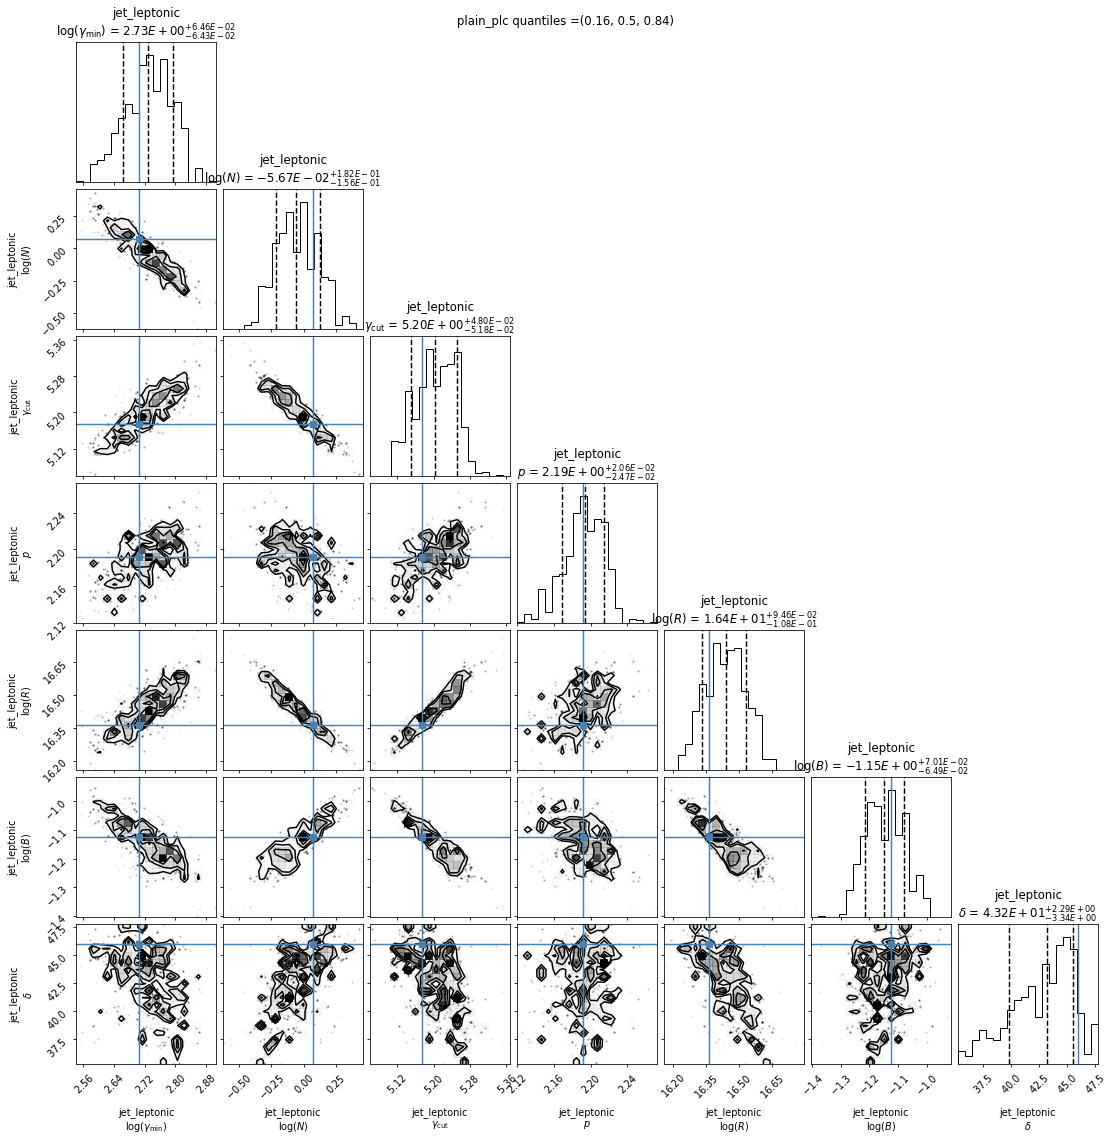

In [28]:
mpl.rcParams['figure.dpi'] = 70
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

### plotting the model

To plot the sampled model range against the input mcmc best-fit model

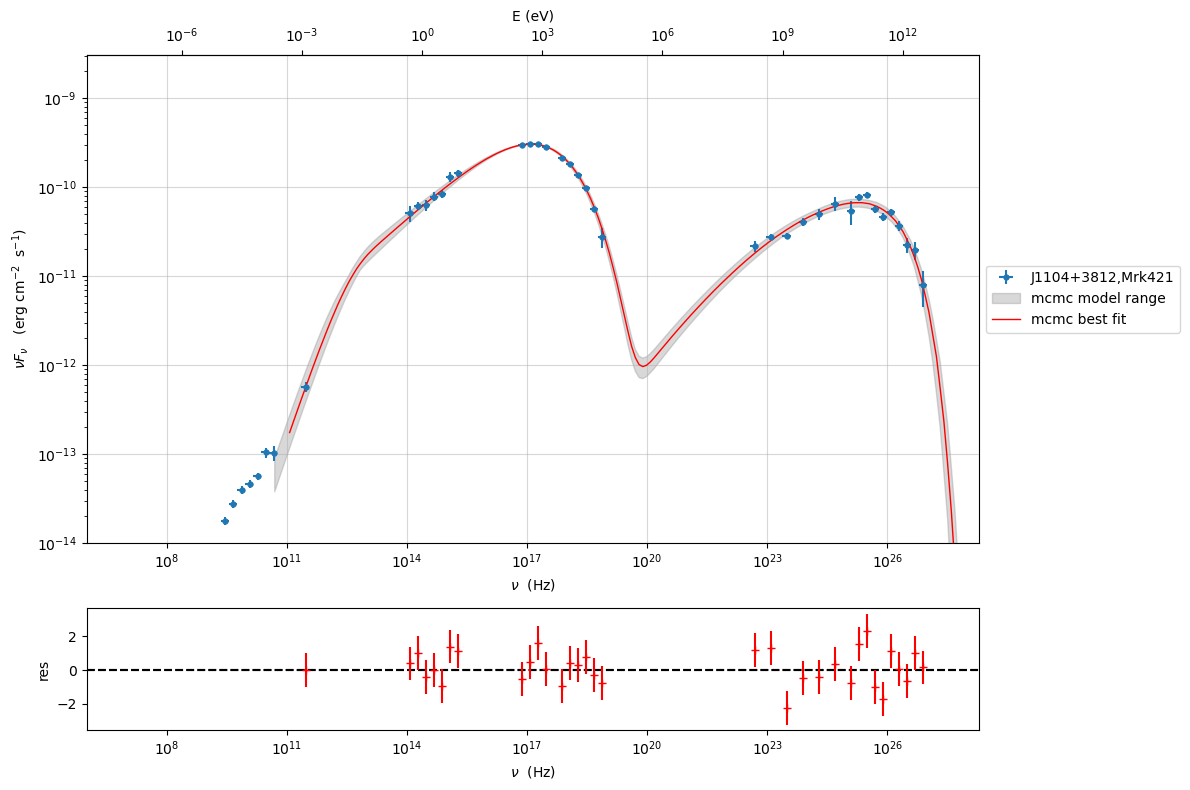

In [29]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=600)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

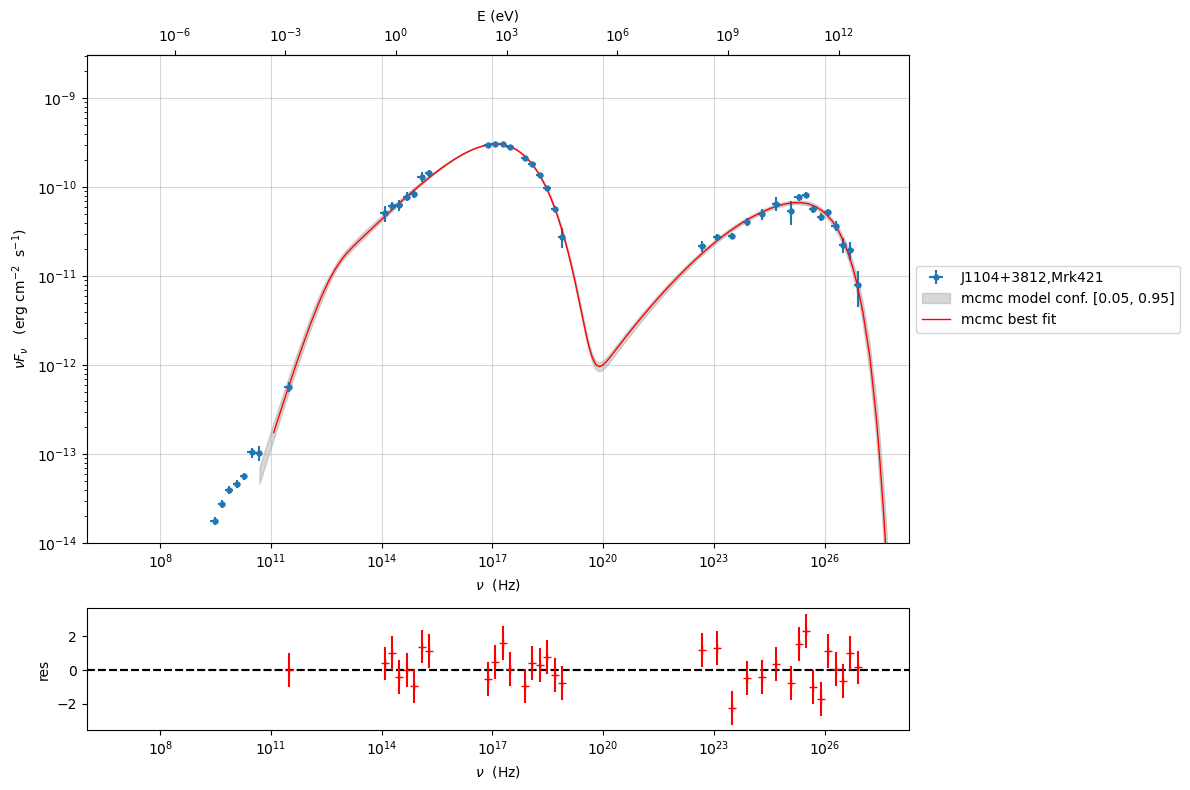

In [30]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

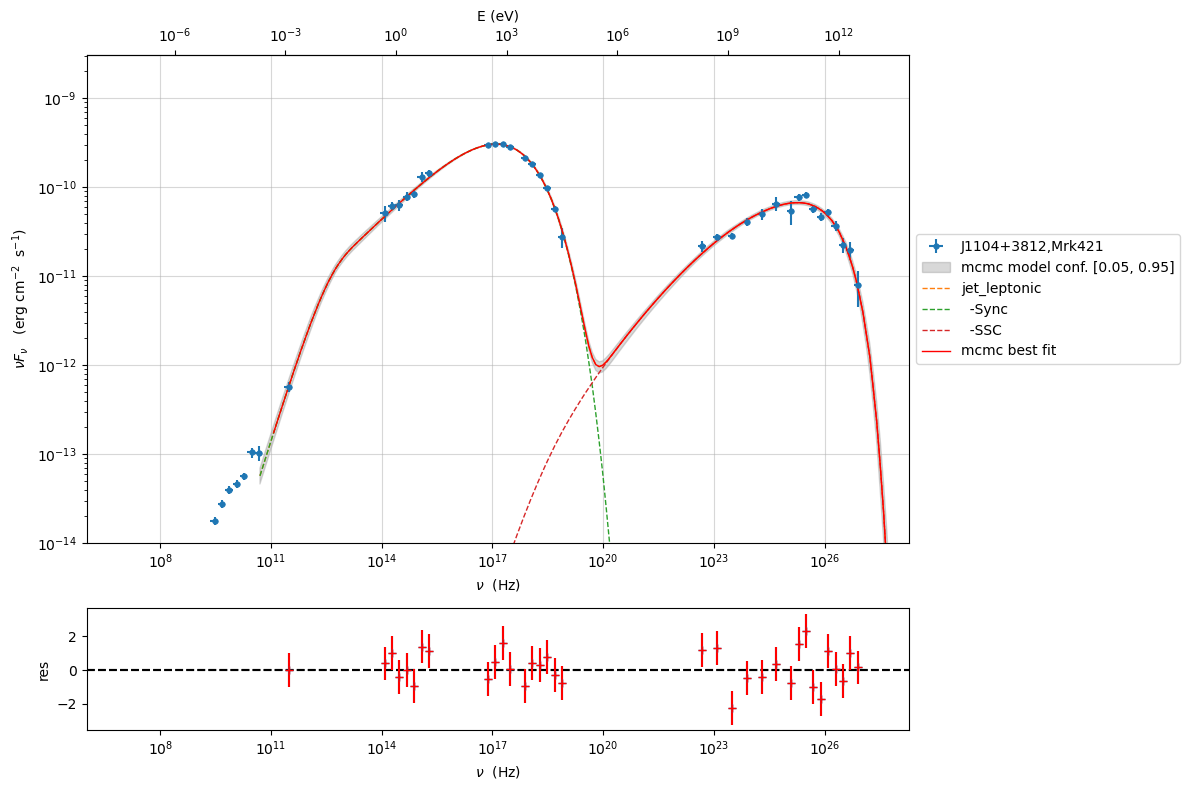

In [31]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)


To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model=False``)

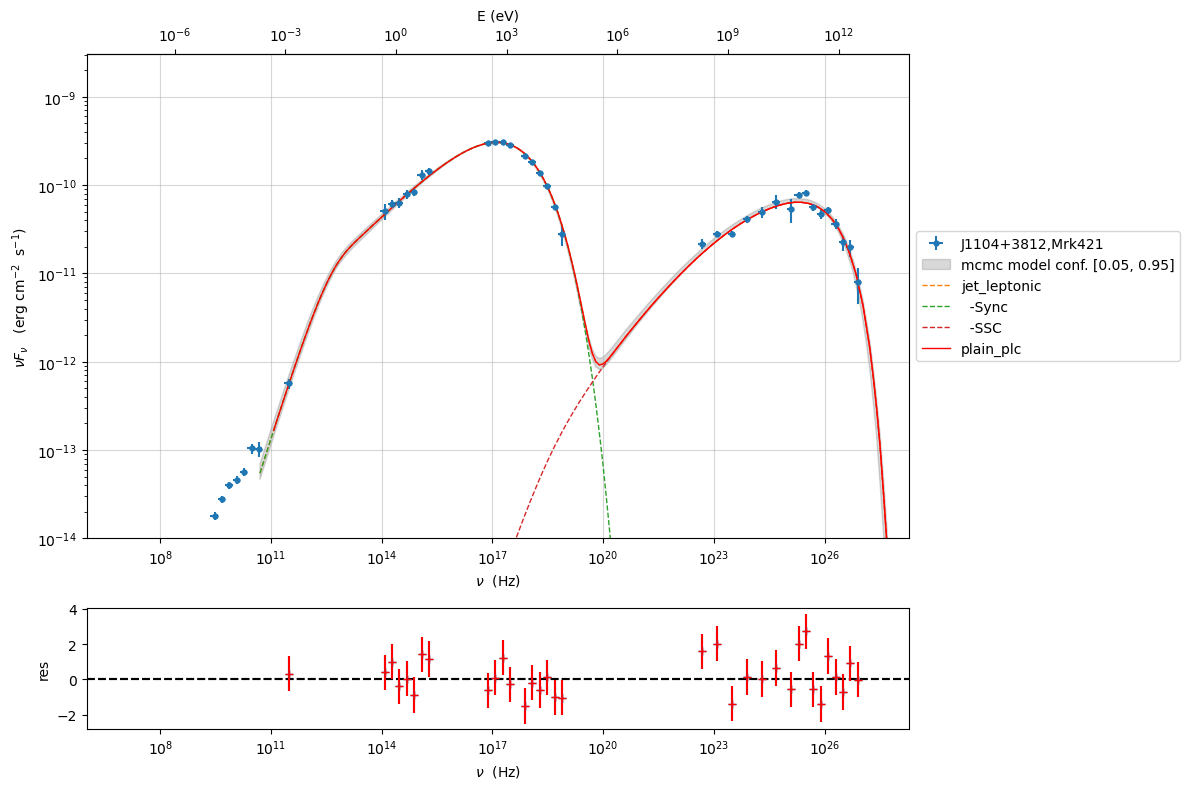

In [32]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

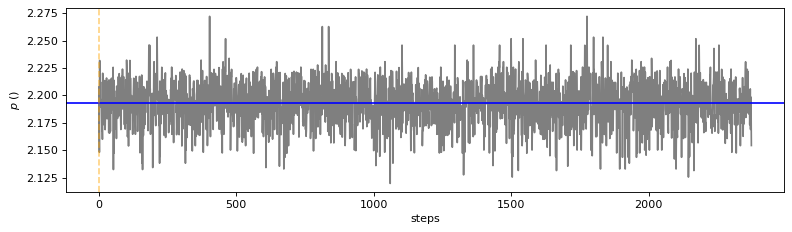

In [33]:
import matplotlib.pylab as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

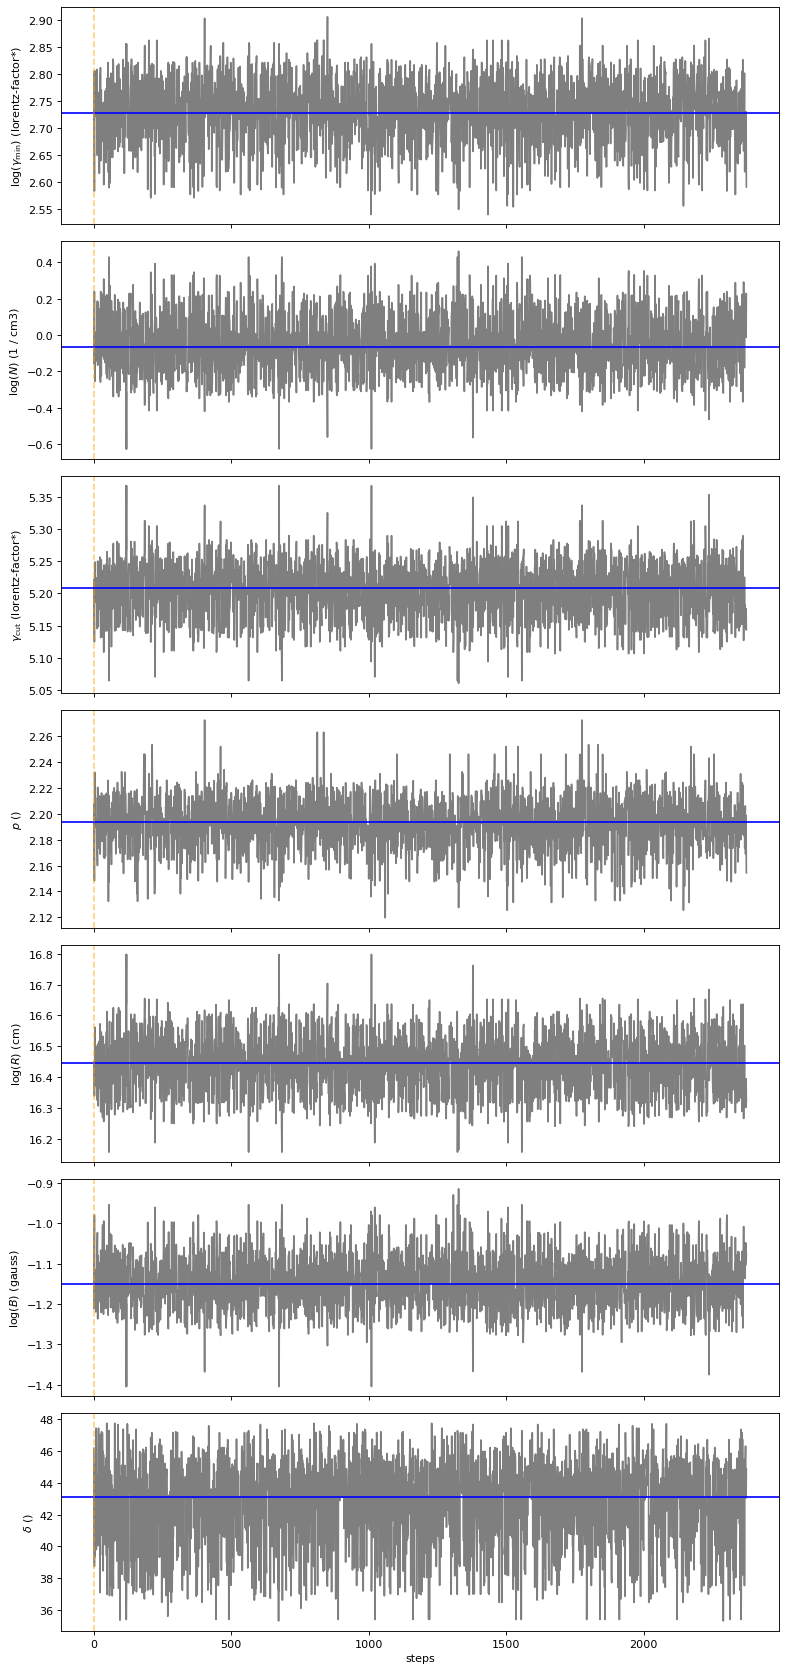

In [34]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

## Saving and reloading the sampler

In [35]:
mcmc.save('mcmc_sampler_ultranest_plain_openmpi.pkl')

In [36]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler_ultranest_plain_openmpi.pkl')

import matplotlib as mpl


In [37]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.703940e+00,True,2.703940e+00,2.667928e+00,2.728645e+00,2.795217e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,6.947924e-02,True,6.947924e-02,-2.233678e-01,-6.351620e-02,1.303388e-01,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.174295e+00,True,5.174295e+00,5.154576e+00,5.207866e+00,5.251339e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.191737e+00,False,2.191737e+00,2.173300e+00,2.193458e+00,2.213100e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.636177e+01,True,1.636177e+01,1.633295e+01,1.644526e+01,1.654025e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.125247e+00,True,-1.125247e+00,-1.214193e+00,-1.150204e+00,-1.078924e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,4.600912e+01,False,4.600912e+01,3.951106e+01,4.309077e+01,4.548385e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


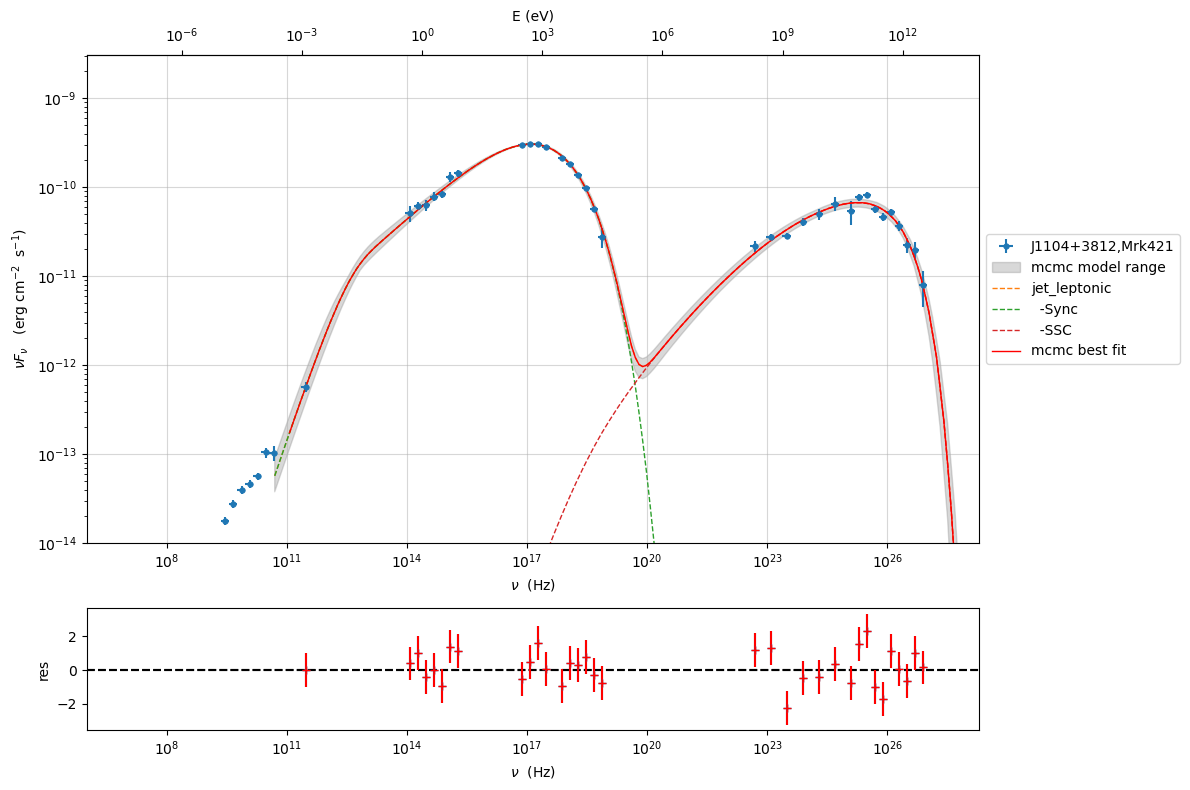

In [38]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

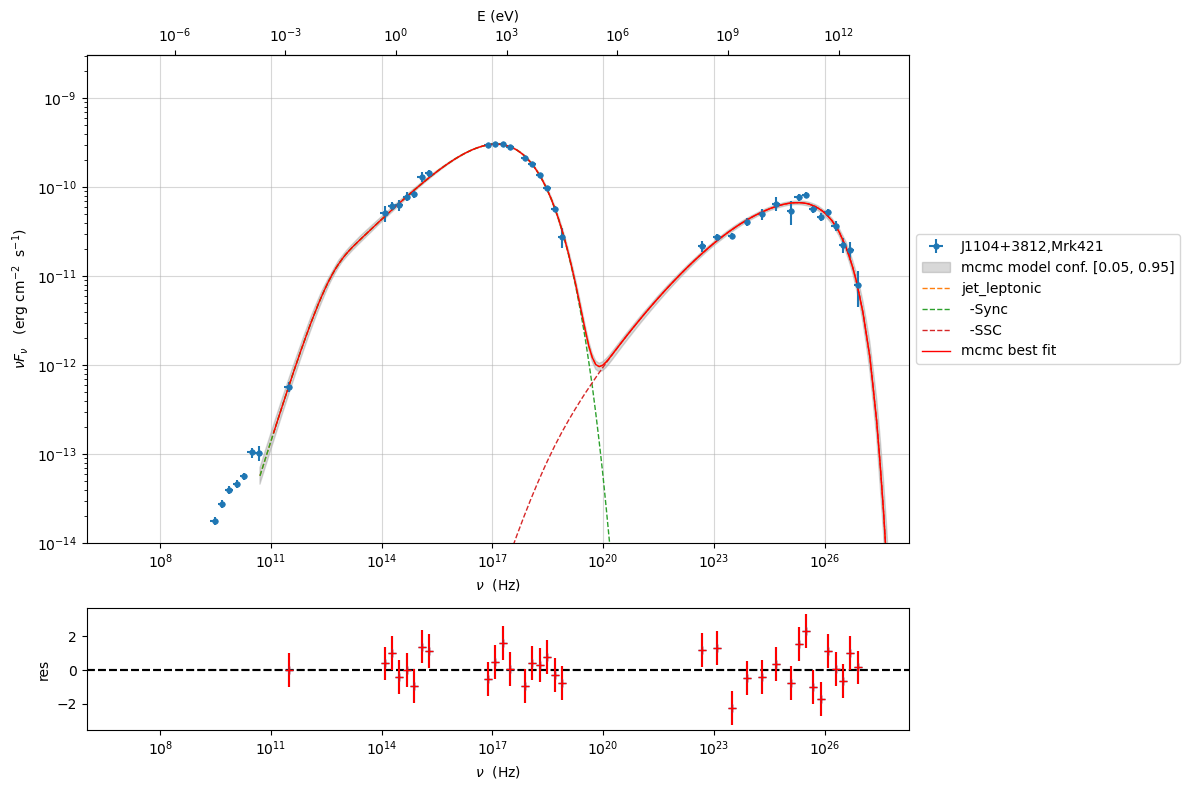

In [39]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

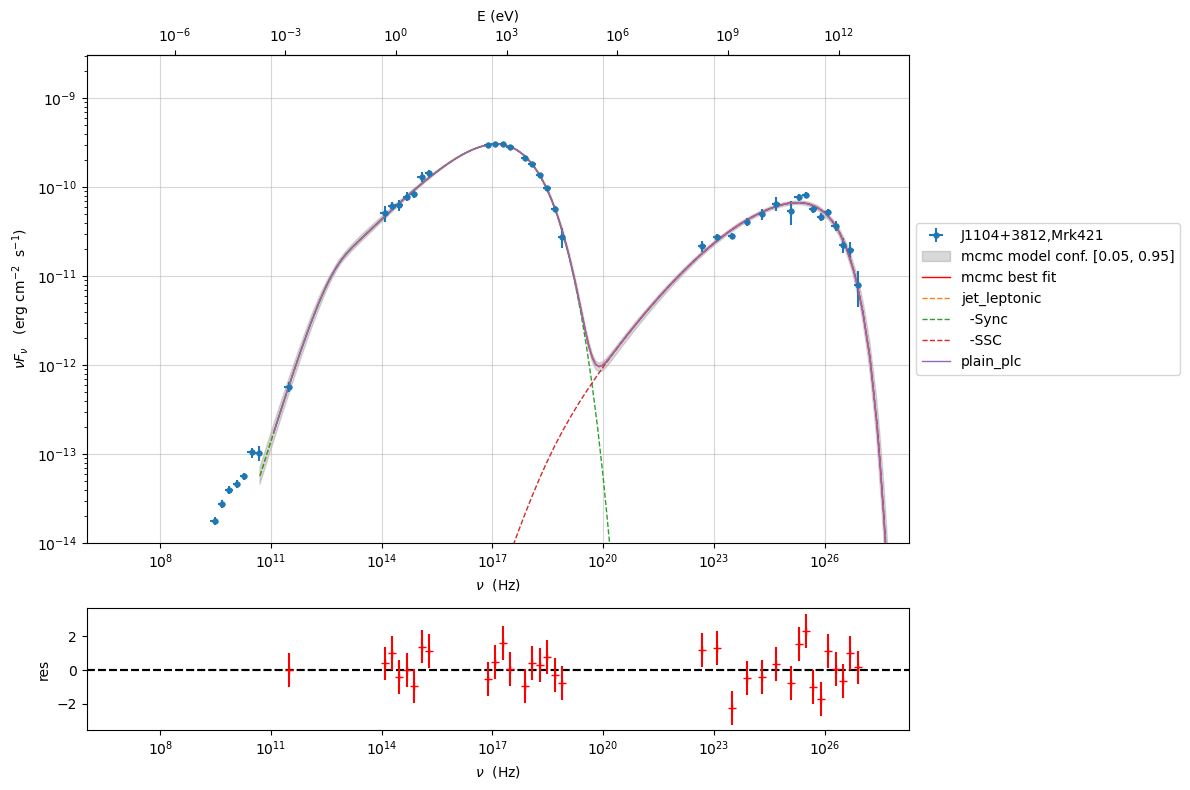

In [40]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

Per-component corner plot

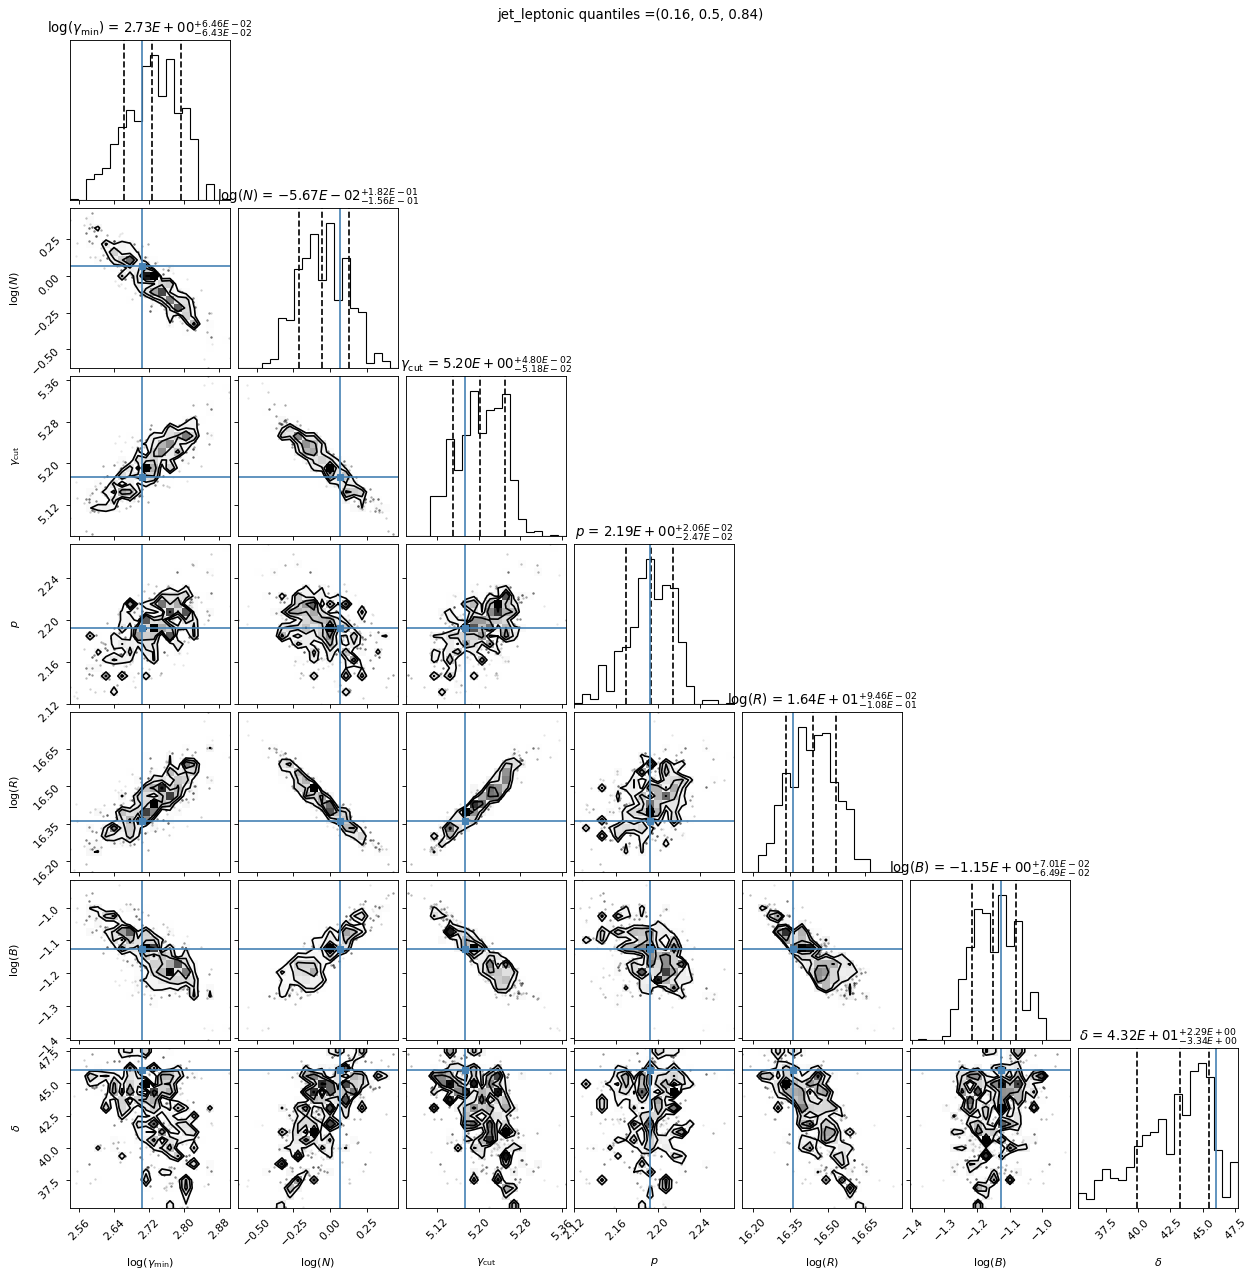

In [41]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


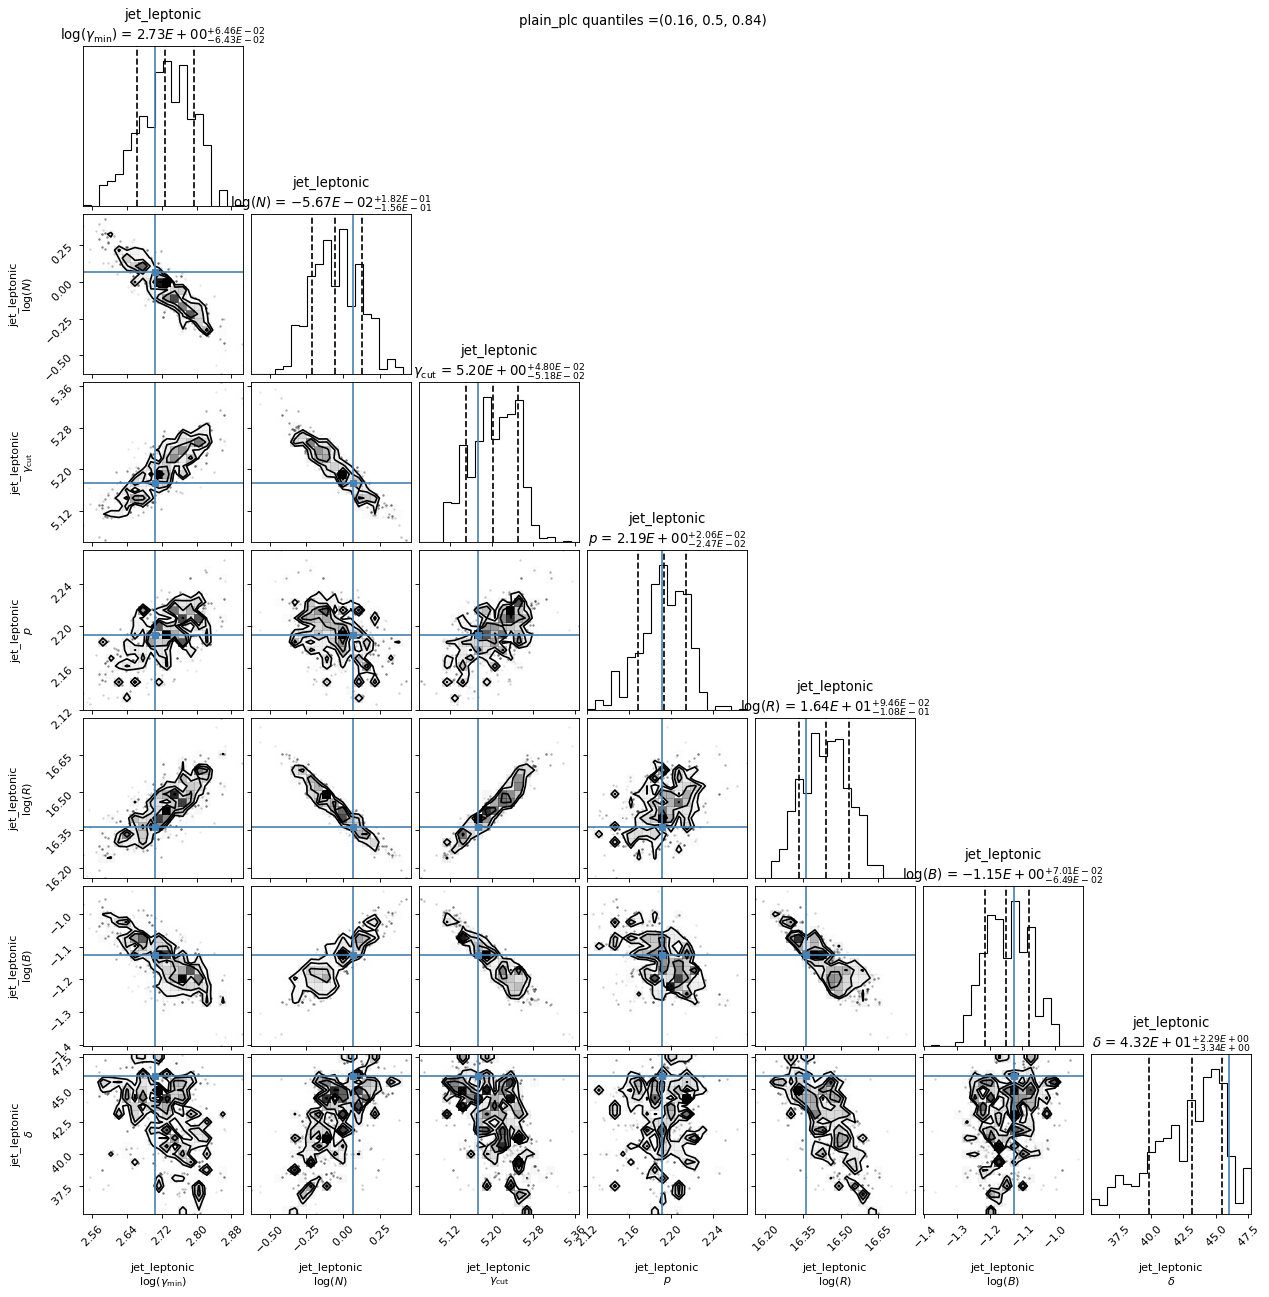

In [42]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)